<a href="https://colab.research.google.com/github/wallynovak/fumarase_kinetics/blob/main/Tecan_kinetic_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tecan Kinetic Processing

This notebook takes an unedited csv file and processes the kinetics in a stepwise manner. Please upload your csv file before proceeding.


## Step 1. Enter your filename

In [7]:
# Sets the filename of the csv to process
fname = input("Please enter the name of your CSV file (e.g. \"Wally Wabash Kinetics.csv\"): ")
file_path = "/content/"+fname

print(f"File path: {file_path}")

Please enter the name of your CSV file (e.g. "Wally Wabash Kinetics.csv"): fumCtest.csv
File path: /content/fumCtest.csv


## Step 2. Importing the kinetic data

Here we identify the data to import into a python dataframe using the keywords "kinetic measurement" and "End Time". In the next section we will clean up the dataframe.

In [62]:
import pandas as pd
import io

try:
    # Read all lines from the CSV file to efficiently find start and end markers
    with open(file_path, 'r') as f:
        all_lines = f.readlines()

    start_row_index = -1  # 0-indexed line number of the header row for the DataFrame
    end_row_index = -1    # 0-indexed line number *after* the last data row

    found_start_marker = False
    for i, line in enumerate(all_lines):
        # Assuming the CSV uses comma as a delimiter. Adjust line.split(',') if needed.
        first_cell_value = line.split(',')[0].strip()

        if not found_start_marker:
            if first_cell_value == "kinetic measurement":
                start_row_index = i
                found_start_marker = True
        elif found_start_marker:
            # Once 'kinetic measurement' is found, look for 'End Time'
            if first_cell_value == "End Time":
                end_row_index = i-2 # back it up if we read 'End Time'
                break # Stop searching once 'End Time' is found

    if start_row_index == -1:
        print(f"Error: 'kinetic measurement' not found in the first column of '{file_path}'.")
        df = pd.DataFrame() # Initialize an empty DataFrame
    else:
        # Calculate the number of rows to read
        if end_row_index == -1:
            # 'End Time' not found, read until the end of the file from the start_row_index
            nrows_to_read = len(all_lines) - start_row_index
        else:
            # Read from start_row_index up to, but not including, end_row_index
            nrows_to_read = end_row_index - start_row_index

        # Import the relevant section of the CSV into a Pandas DataFrame
        # skiprows: Skips lines from the beginning of the file up to the start_row_index.
        # header=0: The first line *after* skipping (i.e., the line at start_row_index) is used as the header.
        # nrows: Reads the specified number of rows after the header.
        df = pd.read_csv(
            file_path,
            skiprows=start_row_index,
            nrows=nrows_to_read,
            header=0 # The line at `start_row_index` is used as the header
        )
        print("DataFrame 'df' created successfully with the kinetic measurement data:")
        print(df.head())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists.")
    df = pd.DataFrame() # Initialize an empty DataFrame on error
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = pd.DataFrame() # Initialize an empty DataFrame on error

DataFrame 'df' created successfully with the kinetic measurement data:
  kinetic measurement Unnamed: 1  Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  \
0           Cycle Nr.   Time [s]  Temp. [°C]         A1         A2         A3   
1                   1          0          25        NaN        NaN        NaN   
2                   2     10.014        24.9        NaN        NaN        NaN   
3                   3     20.023        24.9        NaN        NaN        NaN   
4                   4     30.029        24.9        NaN        NaN        NaN   

  Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ... Unnamed: 89 Unnamed: 90  \
0         A4         A5         A6         A7  ...          H3          H4   
1        NaN     0.1442     0.1446     0.1412  ...         NaN         NaN   
2        NaN     0.1443     0.1445     0.1411  ...         NaN         NaN   
3        NaN     0.1444     0.1447     0.1412  ...         NaN         NaN   
4        NaN     0.1444     0.1447     0.1413  ...  

In [63]:
df

,kinetic measurement,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98
0,Cycle Nr.,Time [s],Temp. [°C],A1,A2,A3,A4,A5,A6,A7,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
1,1,0,25,NaN,NaN,NaN,NaN,0.1442,0.1446,0.1412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,10.014,24.9,NaN,NaN,NaN,NaN,0.1443,0.1445,0.1411,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,20.023,24.9,NaN,NaN,NaN,NaN,0.1444,0.1447,0.1412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,30.029,24.9,NaN,NaN,NaN,NaN,0.1444,0.1447,0.1413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,40.037,24.9,NaN,NaN,NaN,NaN,0.1445,0.1446,0.1414,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,50.054,25,NaN,NaN,NaN,NaN,0.1445,0.1446,0.1412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,60.062,25.1,NaN,NaN,NaN,NaN,0.1447,0.1448,0.1414,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,70.074,25.1,NaN,NaN,NaN,NaN,0.1446,0.1447,0.1412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,80.092,25.2,NaN,NaN,NaN,NaN,0.1447,0.1449,0.1413,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3. Clean the dataframe.

Notice the data has columns we don't need and lots of cells that are blank (NaN). The code below will retain only the data needed.

In [72]:
# Promote the first row to be the column headers and then drop the original first row
if df.columns[0] != 'Time [min]': # makes sure this wasn't already done
    df.columns = df.iloc[0]
    df = df[1:].reset_index(drop=True)

    # Clean up column names by stripping whitespace
    df.columns = df.columns.str.strip()

    # Define columns to remove explicitly
    columns_to_remove_explicit = ['Cycle Nr.', 'Temp. [°C]']

    # Identify columns that exist in the DataFrame from the explicit list
    existing_explicit_cols = [col for col in columns_to_remove_explicit if col in df.columns]

    # Identify columns that contain any NaN values
    # Note: This checks for *any* NaN. If you only want to drop columns that are *entirely* NaN,
    # you would use `df.isnull().all()` instead of `df.isnull().any()`.
    cols_with_nan = df.columns[df.isnull().any()].tolist()

    # Combine all columns to drop and remove duplicates
    all_cols_to_drop = list(set(existing_explicit_cols + cols_with_nan))

    # Drop the identified columns
    df = df.drop(columns=all_cols_to_drop)
else:
    print("Column headers are already correct")

if 'Time [s]' in df.columns:
    df['Time [s]'] = df['Time [s]'].astype(float) / 60
    df = df.rename(columns={'Time [s]': 'Time [min]'})
    print("Time [s] successfully converted to Time [min].")
else:
    print("'Time [s]' column not found. It might have already been converted to 'Time [min]' or renamed.")

print("DataFrame cleaned successfully. Here's the head of the updated DataFrame:")
print(df.head())

Column headers are already correct
'Time [s]' column not found. It might have already been converted to 'Time [min]' or renamed.
DataFrame cleaned successfully. Here's the head of the updated DataFrame:
0  Time [min]      A5      A6      A7      A8      B5      B6      B7      B8  \
0    0.000000  0.1442  0.1446  0.1412  0.1447   0.133  0.1347  0.1331  0.1307   
1    0.166900  0.1443  0.1445  0.1411  0.1448  0.1346  0.1368  0.1354  0.1341   
2    0.333717  0.1444  0.1447  0.1412  0.1447  0.1357  0.1381  0.1372  0.1362   
3    0.500483  0.1444  0.1447  0.1413  0.1448  0.1366  0.1388  0.1385  0.1378   
4    0.667283  0.1445  0.1446  0.1414  0.1449  0.1371  0.1396  0.1395  0.1389   

0      C5  ...      D7      D8      E5      E6      E7      E8      F5  \
0  0.1862  ...  0.2441  0.2214  0.3591  0.3689  0.3548  0.3155  0.4595   
1  0.1932  ...  0.2653  0.2446  0.3925  0.4099  0.3983  0.3603   0.511   
2   0.199  ...  0.2835   0.272  0.4253  0.4514  0.4405  0.4059  0.5618   
3  0.2037  ...

In [73]:
df

,Time [min],A5,A6,A7,A8,B5,B6,B7,B8,C5,...,D7,D8,E5,E6,E7,E8,F5,F6,F7,F8
0,0.000000,0.1442,0.1446,0.1412,0.1447,0.133,0.1347,0.1331,0.1307,0.1862,...,0.2441,0.2214,0.3591,0.3689,0.3548,0.3155,0.4595,0.462,0.4201,0.4027
1,0.166900,0.1443,0.1445,0.1411,0.1448,0.1346,0.1368,0.1354,0.1341,0.1932,...,0.2653,0.2446,0.3925,0.4099,0.3983,0.3603,0.511,0.5181,0.4768,0.47
2,0.333717,0.1444,0.1447,0.1412,0.1447,0.1357,0.1381,0.1372,0.1362,0.199,...,0.2835,0.272,0.4253,0.4514,0.4405,0.4059,0.5618,0.5768,0.5376,0.5408
3,0.500483,0.1444,0.1447,0.1413,0.1448,0.1366,0.1388,0.1385,0.1378,0.2037,...,0.3003,0.2832,0.4554,0.4896,0.4804,0.4487,0.6092,0.6294,0.592,0.61
4,0.667283,0.1445,0.1446,0.1414,0.1449,0.1371,0.1396,0.1395,0.1389,0.2076,...,0.315,0.2983,0.4833,0.5248,0.5175,0.4902,0.6529,0.6784,0.6426,0.6706
5,0.834233,0.1445,0.1446,0.1412,0.1449,0.1377,0.1399,0.1402,0.1394,0.2105,...,0.3277,0.3111,0.5092,0.557,0.5524,0.5291,0.6935,0.7245,0.6909,0.7243
6,1.001033,0.1447,0.1448,0.1414,0.1448,0.1381,0.1403,0.1405,0.1397,0.2128,...,0.3383,0.3229,0.5342,0.5873,0.5852,0.5657,0.7319,0.7688,0.7363,0.7732
7,1.167900,0.1446,0.1447,0.1412,0.1448,0.1383,0.1404,0.1409,0.1399,0.2149,...,0.3471,0.3331,0.558,0.6143,0.616,0.5995,0.7688,0.8105,0.7794,0.8212
8,1.334867,0.1447,0.1449,0.1413,0.145,0.1385,0.1408,0.141,0.1405,0.2164,...,0.3545,0.3423,0.5803,0.6406,0.6458,0.6313,0.8042,0.8513,0.8209,0.8672
9,1.501650,0.1445,0.1447,0.1413,0.1449,0.1386,0.1406,0.141,0.1404,0.2178,...,0.3608,0.3512,0.6015,0.6645,0.6734,0.66,0.8386,0.8901,0.8624,0.9115


## Step 4. Output the dataframe to a csv file
The data can be printed and included in your lab notebook or used in excel.

In [74]:
output_filename = 'processed_data.csv'
df.to_csv(output_filename, index=False)
print(f"DataFrame successfully saved to {output_filename}")

DataFrame successfully saved to processed_data.csv


In [75]:
df

,Time [min],A5,A6,A7,A8,B5,B6,B7,B8,C5,...,D7,D8,E5,E6,E7,E8,F5,F6,F7,F8
0,0.000000,0.1442,0.1446,0.1412,0.1447,0.133,0.1347,0.1331,0.1307,0.1862,...,0.2441,0.2214,0.3591,0.3689,0.3548,0.3155,0.4595,0.462,0.4201,0.4027
1,0.166900,0.1443,0.1445,0.1411,0.1448,0.1346,0.1368,0.1354,0.1341,0.1932,...,0.2653,0.2446,0.3925,0.4099,0.3983,0.3603,0.511,0.5181,0.4768,0.47
2,0.333717,0.1444,0.1447,0.1412,0.1447,0.1357,0.1381,0.1372,0.1362,0.199,...,0.2835,0.272,0.4253,0.4514,0.4405,0.4059,0.5618,0.5768,0.5376,0.5408
3,0.500483,0.1444,0.1447,0.1413,0.1448,0.1366,0.1388,0.1385,0.1378,0.2037,...,0.3003,0.2832,0.4554,0.4896,0.4804,0.4487,0.6092,0.6294,0.592,0.61
4,0.667283,0.1445,0.1446,0.1414,0.1449,0.1371,0.1396,0.1395,0.1389,0.2076,...,0.315,0.2983,0.4833,0.5248,0.5175,0.4902,0.6529,0.6784,0.6426,0.6706
5,0.834233,0.1445,0.1446,0.1412,0.1449,0.1377,0.1399,0.1402,0.1394,0.2105,...,0.3277,0.3111,0.5092,0.557,0.5524,0.5291,0.6935,0.7245,0.6909,0.7243
6,1.001033,0.1447,0.1448,0.1414,0.1448,0.1381,0.1403,0.1405,0.1397,0.2128,...,0.3383,0.3229,0.5342,0.5873,0.5852,0.5657,0.7319,0.7688,0.7363,0.7732
7,1.167900,0.1446,0.1447,0.1412,0.1448,0.1383,0.1404,0.1409,0.1399,0.2149,...,0.3471,0.3331,0.558,0.6143,0.616,0.5995,0.7688,0.8105,0.7794,0.8212
8,1.334867,0.1447,0.1449,0.1413,0.145,0.1385,0.1408,0.141,0.1405,0.2164,...,0.3545,0.3423,0.5803,0.6406,0.6458,0.6313,0.8042,0.8513,0.8209,0.8672
9,1.501650,0.1445,0.1447,0.1413,0.1449,0.1386,0.1406,0.141,0.1404,0.2178,...,0.3608,0.3512,0.6015,0.6645,0.6734,0.66,0.8386,0.8901,0.8624,0.9115


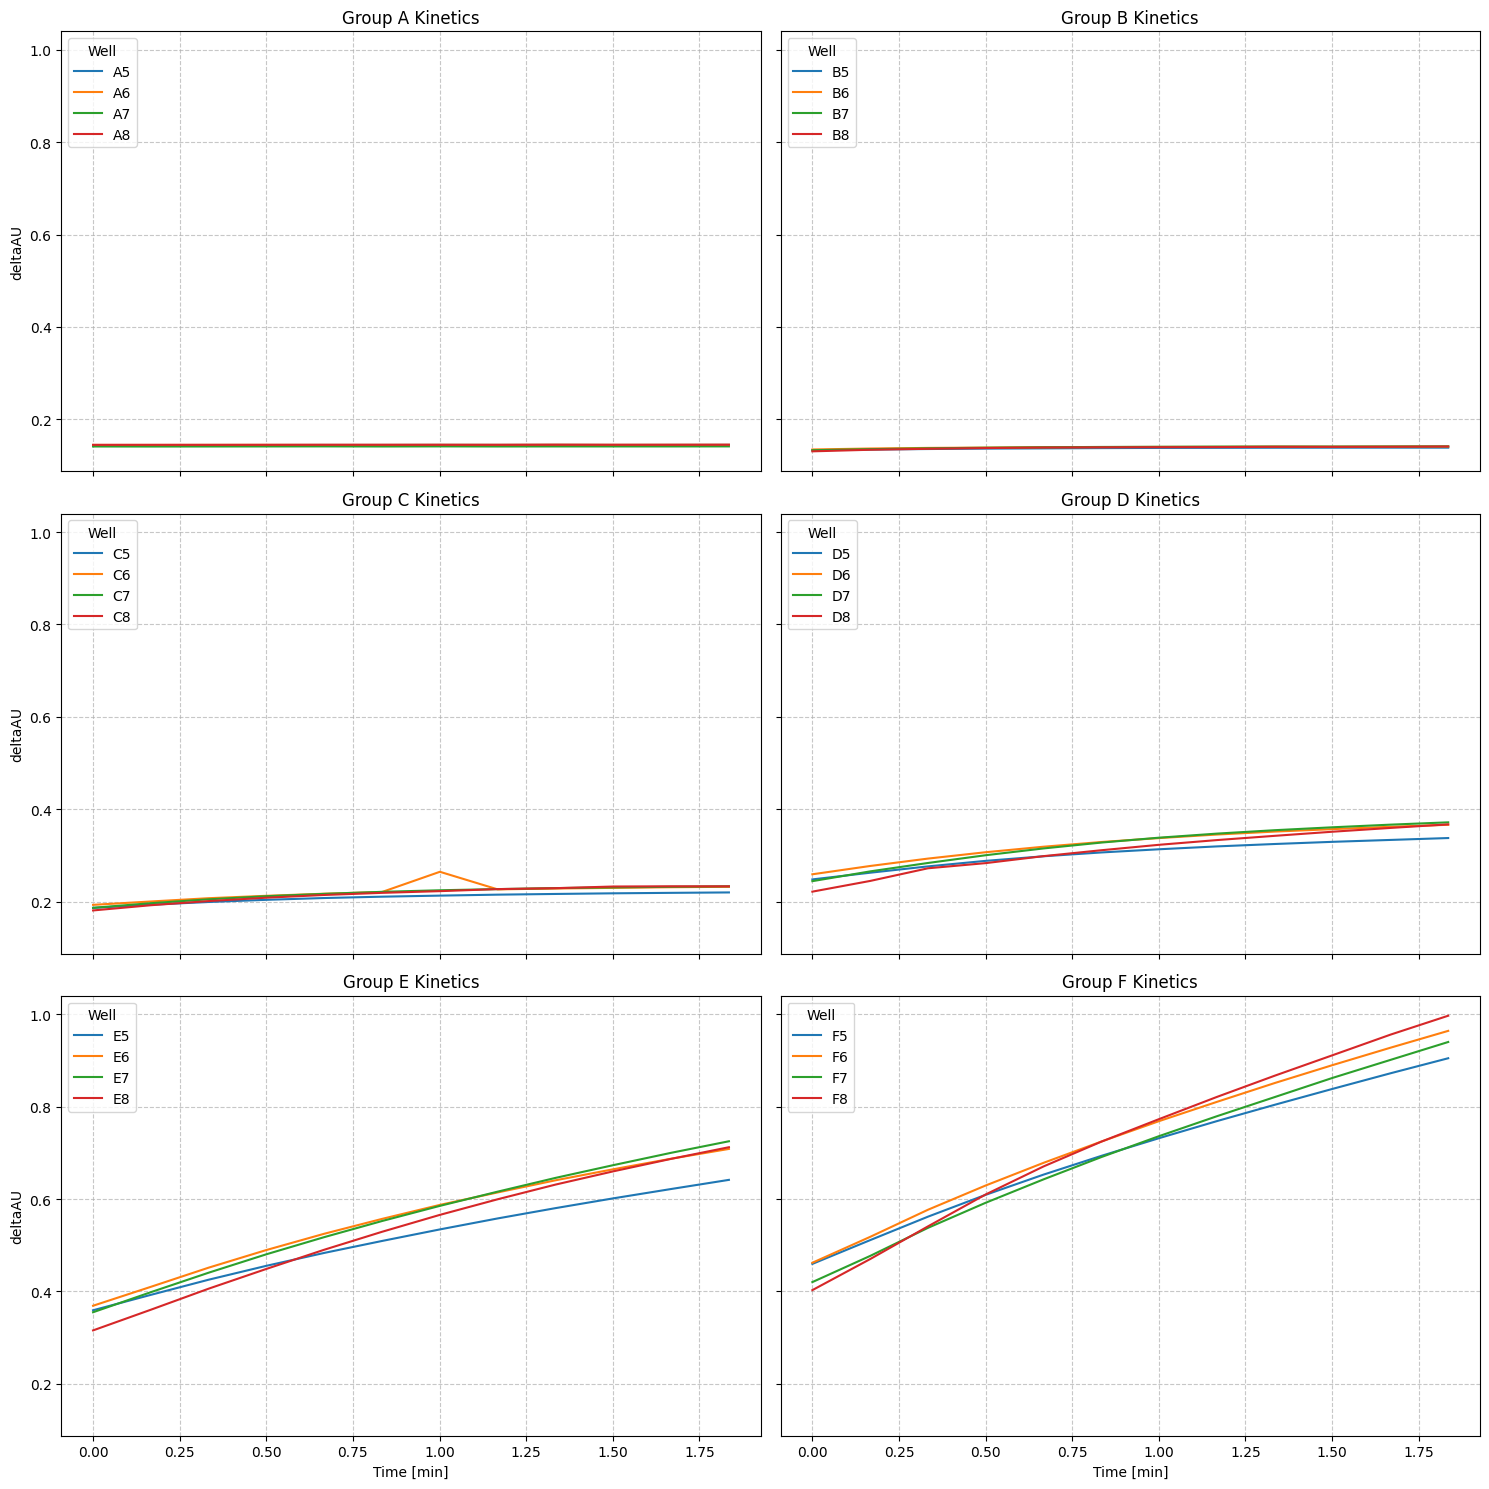

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the groups and their respective column suffixes
groups = ['A', 'B', 'C', 'D', 'E', 'F']
column_suffixes = ['5', '6', '7', '8']

# Create a figure and a set of subplots (3 rows, 2 columns for 6 graphs)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15), sharex=True, sharey=True)
axes = axes.flatten() # Flatten the 3x2 array of axes for easy iteration

# Iterate through each group to create a subplot
for i, group_prefix in enumerate(groups):
    ax = axes[i]
    y_cols = [f'{group_prefix}{suffix}' for suffix in column_suffixes]

    # Check if the 'Time [min]' column exists and convert to float
    if 'Time [min]' not in df.columns:
        print(f"Error: 'Time [min]' column not found in the DataFrame. Cannot plot Group {group_prefix}.")
        ax.set_title(f'Group {group_prefix} (Time [min] Missing)')
        ax.set_xlabel('Time [min]')
        ax.set_ylabel('deltaAU')
        continue

    time_data = df['Time [min]'].astype(float)

    # Plot each series for the current group
    for col in y_cols:
        if col in df.columns:
            sns.lineplot(x=time_data, y=df[col].astype(float), ax=ax, label=col)
        else:
            print(f"Warning: Column '{col}' not found for Group {group_prefix}.")

    ax.set_title(f'Group {group_prefix} Kinetics')
    ax.set_xlabel('Time [min]')
    ax.set_ylabel('deltaAU')
    ax.legend(title='Well', loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


In [77]:
from scipy.stats import linregress
import numpy as np

# Define the groups and their respective column suffixes (as used in plotting)
groups = ['A', 'B', 'C', 'D', 'E', 'F']
column_suffixes = ['5', '6', '7', '8']

print("--- Linear Regression Analysis ---")
print("Each slope is in deltaAU/min.")
print("----------------------------------")

all_group_slopes = {}

for group_prefix in groups:
    group_slopes = []
    print(f"\nGroup {group_prefix}:")

    # Check if 'Time [min]' column exists
    if 'Time [min]' not in df.columns:
        print(f"  Error: 'Time [min]' column not found. Cannot calculate slopes for Group {group_prefix}.")
        continue

    time_data = df['Time [min]'].astype(float)

    for suffix in column_suffixes:
        col = f'{group_prefix}{suffix}'
        if col in df.columns:
            y_data = df[col].astype(float)

            # Perform linear regression
            # Only consider non-NaN values for regression if any
            valid_indices = ~y_data.isnull()
            if valid_indices.any():
                slope, intercept, r_value, p_value, std_err = linregress(time_data[valid_indices], y_data[valid_indices])
                r_squared = r_value**2
                group_slopes.append(slope)
                print(f"  Column {col}: Slope = {slope:.4f}, R² = {r_squared:.4f}")
            else:
                print(f"  Column {col}: No valid data points for regression.")
        else:
            print(f"  Column {col}: Not found in DataFrame.")

    if group_slopes:
        avg_slope = np.mean(group_slopes)
        std_dev_slope = np.std(group_slopes)
        all_group_slopes[group_prefix] = {'average_slope': avg_slope, 'std_dev_slope': std_dev_slope}
        print(f"  Average Slope for Group {group_prefix}: {avg_slope:.4f} +/- {std_dev_slope:.4f}")
    else:
        print(f"  No valid slopes calculated for Group {group_prefix}.")

print("\n--- Summary of Group Slopes ---")
for group, data in all_group_slopes.items():
    print(f"Group {group}: Average Slope = {data['average_slope']:.4f} +/- {data['std_dev_slope']:.4f}")


--- Linear Regression Analysis ---
Each slope is in deltaAU/min.
----------------------------------

Group A:
  Column A5: Slope = 0.0002, R² = 0.7183
  Column A6: Slope = 0.0001, R² = 0.5115
  Column A7: Slope = 0.0001, R² = 0.3153
  Column A8: Slope = 0.0001, R² = 0.6109
  Average Slope for Group A: 0.0001 +/- 0.0001

Group B:
  Column B5: Slope = 0.0028, R² = 0.8321
  Column B6: Slope = 0.0029, R² = 0.7917
  Column B7: Slope = 0.0039, R² = 0.7937
  Column B8: Slope = 0.0046, R² = 0.7770
  Average Slope for Group B: 0.0035 +/- 0.0008

Group C:
  Column C5: Slope = 0.0171, R² = 0.9078
  Column C6: Slope = 0.0213, R² = 0.4796
  Column C7: Slope = 0.0238, R² = 0.8966
  Column C8: Slope = 0.0274, R² = 0.9093
  Average Slope for Group C: 0.0224 +/- 0.0037

Group D:
  Column D5: Slope = 0.0472, R² = 0.9510
  Column D6: Slope = 0.0566, R² = 0.9519
  Column D7: Slope = 0.0677, R² = 0.9508
  Column D8: Slope = 0.0755, R² = 0.9630
  Average Slope for Group D: 0.0617 +/- 0.0108

Group E:
  Colu